Estimated π: 3.14412
True π: 3.141592653589793


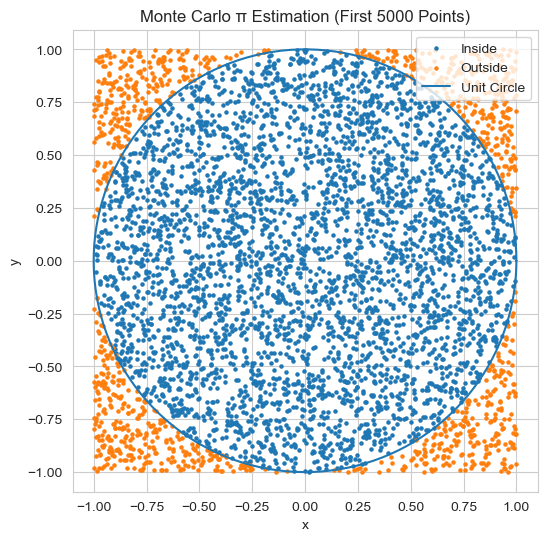

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")

N = 100000

# Generate random points
x = np.random.uniform(-1, 1, N) 
y = np.random.uniform(-1, 1, N) 

# Check if inside circle
inside = x**2 + y**2 <= 1

# Estimate pi
points_inside = np.sum(inside)
pi_estimate = 4 * points_inside / N

print("Estimated π:", pi_estimate) 
print("True π:", np.pi) 

# -------------------
# Scatter Plot
# -------------------

n_plot = 5000

plt.figure(figsize=(6,6))

plt.scatter(x[:n_plot][inside[:n_plot]],
            y[:n_plot][inside[:n_plot]],
            s=5,
            label="Inside")

plt.scatter(x[:n_plot][~inside[:n_plot]],
            y[:n_plot][~inside[:n_plot]],
            s=5,
            label="Outside")

# Draw circle
theta = np.linspace(0, 2*np.pi, 300)
circle_x = np.cos(theta)
circle_y = np.sin(theta)

plt.plot(circle_x, circle_y, label="Unit Circle")

plt.title("Monte Carlo π Estimation (First 5000 Points)") 
plt.xlabel("x") 
plt.ylabel("y") 
plt.legend() 
plt.axis("equal") 
 
plt.show() 

Task 2: Coin Flips and Empirical Probability
##### Simulate a series of fair coin flips and observe how the empirical probability of heads converges to 0.5.

##### Simulate 10,000 fair coin flips (use np.random.choice([0, 1]) or np.random.binomial(1, 0.5, size=10000)).
##### Compute the running proportion of heads after each flip (cumulative sum divided by cumulative count).
##### Plot the running proportion with a horizontal line at 0.5. Use a log-scaled x-axis so you can see early fluctuations and later stabilization clearly.
##### Repeat the experiment 5 times (5 independent series of 10,000 flips) and overlay all 5 convergence paths on the same plot with different colors.
##### Guiding question: How many flips does it typically take for the running proportion to stay within ±0.01 of 0.5?

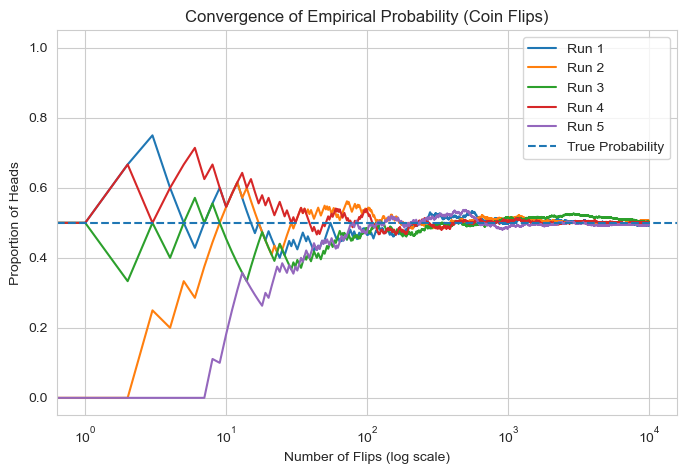

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42) 
sns.set_style("whitegrid") 

N = 10000 

plt.figure(figsize=(8,5)) 

for i in range(5): 

    flips = np.random.binomial(1, 0.5, size=N) 

    cumulative_heads = np.cumsum(flips)  

    running_proportion = cumulative_heads / np.arange(1, N + 1)  

    plt.plot(running_proportion, label=f"Run {i+1}") 

plt.axhline(0.5, linestyle="--", label="True Probability") 

plt.xscale("log") 

plt.title("Convergence of Empirical Probability (Coin Flips)") 
plt.xlabel("Number of Flips (log scale)") 
plt.ylabel("Proportion of Heads") 

plt.legend() 

plt.show() 

Task 3: Simulating Binomial Experiments
##### A factory produces widgets with a 3% defect rate. A quality inspector samples 50 widgets per batch.

##### Simulate 10,000 batches of 50 widgets each, where each widget has a 3% chance of being defective.
##### For each batch, record the number of defective widgets found.
##### Plot a histogram of the defect counts across all 10,000 batches. Overlay the theoretical Binomial(n=50, p=0.03) PMF as points connected by a line.
##### From your simulation, estimate:
##### P(0 defects in a batch)
##### P(3 or more defects in a batch)
##### The expected number of defects per batch
##### Compare each simulation estimate to the theoretical binomial value (use scipy.stats.binom or manual calculation).
##### Guiding question: How close are your empirical estimates to the theoretical values? Would 1,000 batches have been enough, or do you need 10,000?

NameError: name 'binom' is not defined

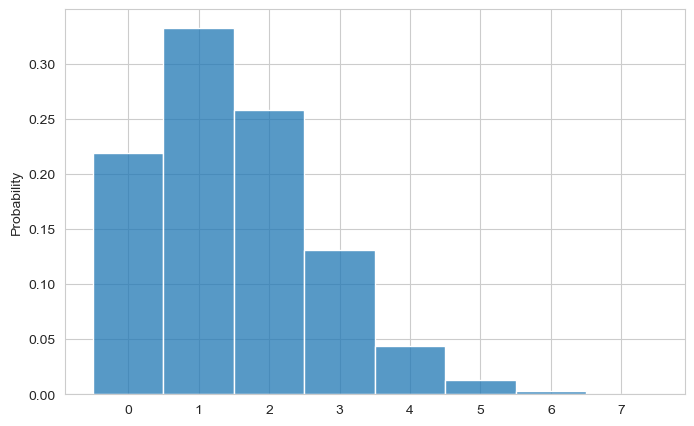

In [8]:
n = 50
p = 0.03
batches = 10000

defects = np.random.binomial(n, p, size=batches)

plt.figure(figsize=(8,5))

sns.histplot(defects, bins=range(0,10), stat="probability", discrete=True)

k = np.arange(0,10)
pmf = binom.pmf(k, n, p)

plt.plot(k, pmf, marker='o', label="Binomial PMF")

plt.title("Defects per Batch (Simulation vs Binomial Theory)")
plt.xlabel("Number of Defects")
plt.ylabel("Probability")

plt.legend()
plt.show()

p0_sim = np.mean(defects == 0)
p3_sim = np.mean(defects >= 3)
expected_sim = np.mean(defects)

p0_theory = binom.pmf(0, n, p)
p3_theory = 1 - binom.cdf(2, n, p)
expected_theory = n * p

print("Simulation Results")
print("P(0 defects):", p0_sim)
print("P(3+ defects):", p3_sim)
print("Expected defects:", expected_sim)

print("\nTheoretical Results")
print("P(0 defects):", p0_theory)
print("P(3+ defects):", p3_theory)
print("Expected defects:", expected_theory)